In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud

In [4]:
!wget -nc https://lazyprogrammer.me/course_files/AirlineTweets.csv

File ‘AirlineTweets.csv’ already there; not retrieving.



In [5]:
df = pd.read_csv('AirlineTweets.csv')

In [6]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [7]:
df = df[['airline_sentiment', 'text']].copy()

In [8]:
df

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...
...,...,...
14635,positive,@AmericanAir thank you we got on a different f...
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,@AmericanAir Please bring American Airlines to...
14638,negative,"@AmericanAir you have my money, you change my ..."


<Axes: >

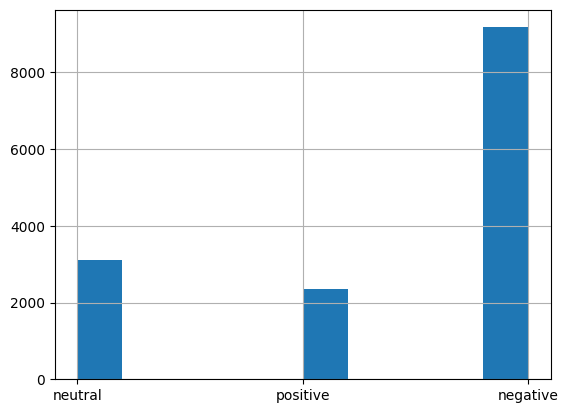

In [9]:
df['airline_sentiment'].hist()

In [10]:
target_map = {
    'positive':1,
    'negative':0,
    'neutral':2
}
df['target'] = df['airline_sentiment'].map(target_map)


In [11]:
df

,airline_sentiment,text,target
0,neutral,@VirginAmerica What @dhepburn said.,2
1,positive,@VirginAmerica plus you've added commercials t...,1
2,neutral,@VirginAmerica I didn't today... Must mean I n...,2
3,negative,@VirginAmerica it's really aggressive to blast...,0
4,negative,@VirginAmerica and it's a really big bad thing...,0
...,...,...,...
14635,positive,@AmericanAir thank you we got on a different f...,1
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...,0
14637,neutral,@AmericanAir Please bring American Airlines to...,2
14638,negative,"@AmericanAir you have my money, you change my ...",0


In [12]:
df_train, df_test = train_test_split(df)

In [13]:
df_train.head()

,airline_sentiment,text,target
9183,negative,@USAirways membership has no privileges anymor...,0
11636,negative,@USAirways stuck in Charlotte being treated li...,0
2196,negative,@united it was eventually explained that weath...,0
9465,negative,@USAirways I am in meetings in California and ...,0
3852,negative,@united But why do people with no status get t...,0


In [16]:
vectorizer = TfidfVectorizer(max_features = 2000)

In [17]:
X_train = vectorizer.fit_transform(df_train['text'])

In [18]:
X_test = vectorizer.transform(df_test['text'])

In [19]:
Y_train = df_train['target']
Y_test = df_test['target']

In [21]:
model = LogisticRegression(max_iter = 500)
model.fit(X_train, Y_train)
print('Train Acc:', model.score(X_train, Y_train))
print('Test Acc:', model.score(X_test, Y_test))

Train Acc: 0.8544626593806922
Test Acc: 0.7950819672131147


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [38]:
Pr_train = model.predict_proba(X_train)
Pr_test = model.predict_proba(X_test)

print('Train AUC:', roc_auc_score(Y_train, Pr_train, multi_class ='ovo'))
print('Test AUC:', roc_auc_score(Y_test, Pr_test, multi_class ='ovo'))


Train AUC: 0.9435613020510559
Test AUC: 0.8929048673481215


In [39]:
P_train = model.predict(X_train)
P_test= model.predict(X_test)

In [40]:
cm = confusion_matrix(Y_train, P_train, normalize = 'true')
cm

array([[0.96385716, 0.00824057, 0.02790227],
       [0.20068611, 0.69754145, 0.10177244],
       [0.30639585, 0.04753673, 0.64606742]])

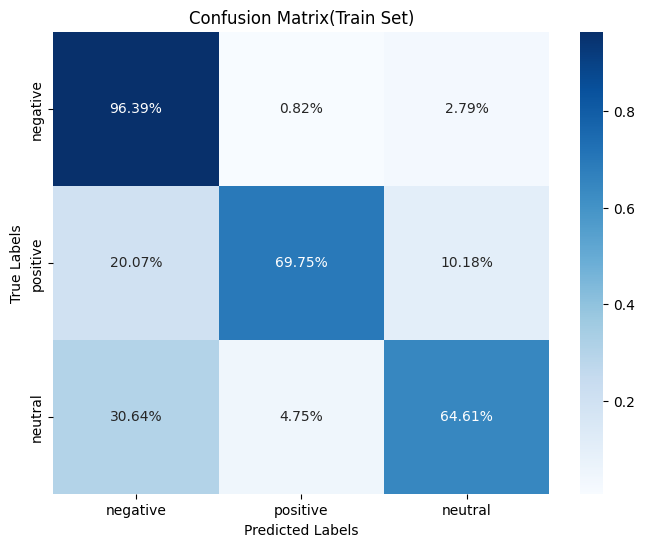

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming cm is the confusion matrix calculated using sklearn confusion_matrix function
# Ytrain is the true labels and Ptrain are the predicted labels or probabilities from your model

# Calculate the confusion matrix
cm = confusion_matrix(Y_train, P_train, normalize = 'true')

# Define class labels
class_names = ['negative', 'positive', 'neutral']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix(Train Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [46]:
cm_test = confusion_matrix(Y_test, P_test)
cm_test

array([[2109,   45,  107],
       [ 146,  376,   92],
       [ 313,   47,  425]])

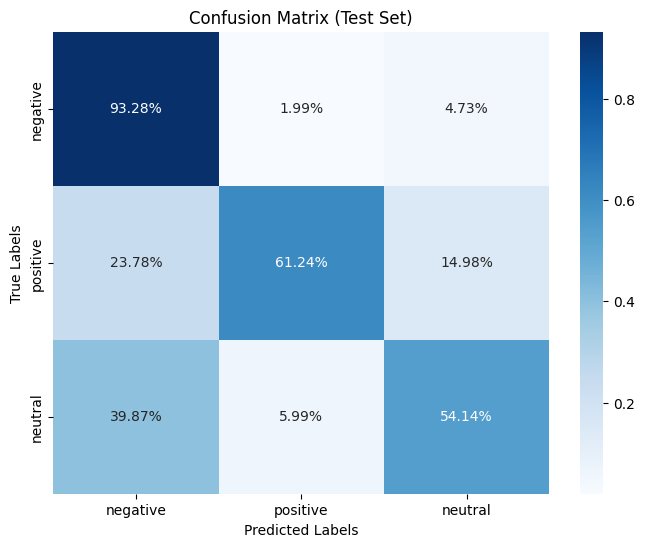

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming cm_test is the confusion matrix calculated using sklearn confusion_matrix function
# Ytest is the true labels and Ptest are the predicted labels or probabilities from your model

# Calculate the confusion matrix for the test set
cm_test = confusion_matrix(Y_test, P_test, normalize = 'true')

# Define class labels
class_names = ['negative', 'positive', 'neutral']

# Plot the confusion matrix for the test set
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [51]:
# Binary Lables and Model Performance

In [53]:
binary_target_list = [target_map['positive'], target_map['negative']]
df_b_train = df_train[df_train['target'].isin(binary_target_list)]
df_b_test = df_test[df_test['target'].isin(binary_target_list)]

In [54]:
df_b_train

,airline_sentiment,text,target
9183,negative,@USAirways membership has no privileges anymor...,0
11636,negative,@USAirways stuck in Charlotte being treated li...,0
2196,negative,@united it was eventually explained that weath...,0
9465,negative,@USAirways I am in meetings in California and ...,0
3852,negative,@united But why do people with no status get t...,0
...,...,...,...
12810,negative,@AmericanAir after several miss communications...,0
14179,negative,@AmericanAir I've been on hold for about 3 and...,0
3805,negative,@united When will that happen? It really confu...,0
1534,negative,@united Why did you load us in this flying sar...,0


In [55]:
X_train = vectorizer.fit_transform(df_b_train['text'])
X_test = vectorizer.transform(df_b_test['text'])

In [56]:
Y_train = df_b_train['target']
Y_test = df_b_test['target']

In [57]:
model = LogisticRegression(max_iter = 500)
model.fit(X_train, Y_train)
print('Train Acc:', model.score(X_train, Y_train))
print('Test Acc:', model.score(X_test, Y_test))

Train Acc: 0.9291483960304638
Test Acc: 0.9078260869565218


In [60]:
Pr_train = model.predict_proba(X_train)[:,1]
Pr_test = model.predict_proba(X_test)[:,1]

print('Train AUC:', roc_auc_score(Y_train, Pr_train))
print('Test AUC:', roc_auc_score(Y_test, Pr_test))


Train AUC: 0.9772106293746986
Test AUC: 0.9604445584165435


In [63]:
word_index_map = vectorizer.vocabulary_
word_index_map

{'usairways': 1869,
 'has': 836,
 'no': 1206,
 'anymore': 157,
 'my': 1183,
 'son': 1624,
 'is': 951,
 'in': 922,
 'the': 1733,
 'short': 1570,
 'window': 1950,
 'to': 1767,
 'see': 1540,
 'him': 864,
 'help': 855,
 'stuck': 1675,
 'charlotte': 347,
 'being': 240,
 'treated': 1796,
 'like': 1035,
 'nobody': 1207,
 'by': 292,
 'staff': 1647,
 'united': 1846,
 'it': 957,
 'was': 1903,
 'eventually': 626,
 'explained': 652,
 'that': 1731,
 'weather': 1916,
 'conditions': 410,
 'too': 1774,
 'get': 787,
 'luggage': 1082,
 'off': 1232,
 'planes': 1337,
 'will': 1947,
 'be': 232,
 'sent': 1550,
 'on': 1247,
 'but': 289,
 'won': 1957,
 'for': 743,
 'days': 483,
 'am': 136,
 'meetings': 1121,
 'california': 295,
 'and': 145,
 'have': 840,
 'why': 1943,
 'do': 553,
 'people': 1308,
 'with': 1953,
 'status': 1658,
 'buy': 290,
 'an': 144,
 'at': 191,
 'much': 1179,
 'less': 1021,
 'than': 1727,
 'cost': 435,
 'ahead': 113,
 'of': 1231,
 'earned': 586,
 'confirmed': 415,
 'great': 809,
 'pls': 13

In [64]:
threshold =2
print("Most Positive words")
for word, index in word_index_map.items():
  weight = model.coef_[0][index]
  if weight > threshold:
    print(word, weight)

Most Positive words
great 5.479799084058293
southwestair 2.4836316771467626
virginamerica 2.915567541062128
jetblue 3.213127462351235
thank 8.219439610472802
thanks 7.799879008061422
good 3.078343039065106
appreciate 3.081697836700502
best 3.7777286120623805
thx 2.624482362696762
love 4.302337221186483
kudos 2.3691845539198995
amazing 4.1120507003267015
awesome 3.995080867629744
wonderful 2.503446574363746
excited 2.2301278104770472
worries 2.586169849717863
excellent 2.329822129703238


In [65]:
print("Most Negative words:")
for word, index in word_index_map.items():
  weight = model.coef_[0][index]
  if weight <- threshold:
    print(word, weight)

Most Negative words:
no -3.7034904221525724
why -2.1235459007460165
delayed -3.0590957386171826
not -4.073422459149478
hours -2.838551288521255
nothing -2.5013630516549012
cancelled -2.842394285631856
hold -2.8649358449657734
worst -3.191868308636667
hour -2.072173649138351
